## Visualization of real microbiome datasets using CKDR

Ternary visualization requires the Python package `ternary`
- You can install it through `pip install python-ternary`
- Documentation: https://github.com/marcharper/python-ternary

In [1]:
import os, sys
os.chdir('..')
# sys.path.insert(0, os.path.abspath('..'))
import pickle

import numpy as np
import pandas as pd
import torch

# Plot helpers
import ternary
from functions.plot_helper import corner_labeling, tern_scatter_decbdry, tern_scatter_cmap
import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
marker_list=['o', 'x']

# Cross-validation -> training functions
from functions.cross_val import ckdr_cv_parallel

# Collapse warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
MASTER_SEED = 20241225

In [2]:
directory = "./datasets/MLRepo/"
x_dir = "/refseq/taxatable.txt"
y_dir = "/task-"  
y_names = {"gevers": "ileum", "ravel": "nugent-score"}

# HMP data (Sections 1-2)
Dataset downloaded from the repository: https://github.com/diegotomassi/sdr4comp
- Paper: Tomassi et al. (2021) ["Sufficient dimension reduction for compositional data"](https://academic.oup.com/biostatistics/article/22/4/687/5689688)

In [3]:
# Load HMP data
compos = pd.read_csv("datasets/HMP/HMPdataL2.txt", header=None)
totals = pd.read_csv("datasets/HMP/HMPdataL2reads.txt", header=None)
labels = pd.read_table("datasets/HMP/HMPlabels.txt", header=None)

counts = np.round(np.array(compos) * np.array(totals))
groups = [None, 'Stool','Saliva','Skin','Nasal','Vagina'] # None for dummy indexing

Y = list()
for i in range(len(labels)):
    Y.append(groups[labels[0][i]])
Y = np.array(Y)

X = np.array(compos)
# Delete taxa less than or equal to 5 counts: consistent with the processing in Tomassi et al. (2021)
X = X[:, counts.sum(0) > 5]  
X = X / X.sum(1)[:, None]

print("Zero ratio:", np.sum(X == 0.) / X.size)
print("(Num_samples, Num_taxa) =", X.shape)

Zero ratio: 0.7348528378982315
(Num_samples, Num_taxa) = (681, 23)


In [ ]:
# Cross-validated CKDR (44sec with 15 cores)
result = ckdr_cv_parallel(X, Y, type_Y="multiclass", folds=5, verbose=True,
                          n_jobs=-3, 
                          seed=MASTER_SEED,
                          )
# Save the result
with open("results/ternary_train/HMP.pkl", "wb") as f:
    pickle.dump(result, f)

Running parallel cross-validation with 10 parameter combinations across 5 folds, totaling 50 individual training tasks.


[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done   2 tasks      | elapsed:   15.6s
[Parallel(n_jobs=-2)]: Done  11 tasks      | elapsed:   21.4s
[Parallel(n_jobs=-2)]: Done  20 tasks      | elapsed:   24.7s
[Parallel(n_jobs=-2)]: Done  27 out of  50 | elapsed:   29.3s remaining:   25.0s
[Parallel(n_jobs=-2)]: Done  33 out of  50 | elapsed:   30.8s remaining:   15.8s
[Parallel(n_jobs=-2)]: Done  39 out of  50 | elapsed:   33.2s remaining:    9.3s
[Parallel(n_jobs=-2)]: Done  45 out of  50 | elapsed:   33.9s remaining:    3.7s
[Parallel(n_jobs=-2)]: Done  50 out of  50 | elapsed:   34.5s finished


\nSelected parameters after 5-fold Cross-validation (parallel):
  target_dim = 3, epsilon = 0.0001, sigma_Z = 0.6816
  Corresponding mean CV score: 0.2345
\nRefitting model with selected best parameters on the full dataset (parallel CV)...
Starting SCA CKDR on device: cpu
  n_samples=681, n_features=23, target_dim=3
  sigma=0.6816, epsilon=0.0001, tol=1.0e-06, inner_tol=1.0e-07
Iter:    0, Obj: 5747.907715, LR: 1.00e+00, ||D||: 1.41e-01, inner residual: 4.09e+00, inner iters: 50
Iter:   10, Obj: 3731.711182, LR: 1.00e+00, ||D||: 1.14e-01, inner residual: 3.63e+00, inner iters: 50
Iter:   20, Obj: 3325.196533, LR: 1.00e+00, ||D||: 5.94e-02, inner residual: 3.12e+00, inner iters: 50
Iter:   30, Obj: 3268.062988, LR: 1.00e+00, ||D||: 3.90e-02, inner residual: 2.68e+00, inner iters: 50
Iter:   40, Obj: 3226.544434, LR: 1.00e+00, ||D||: 2.95e-02, inner residual: 2.39e+00, inner iters: 50
Iter:   50, Obj: 3190.228027, LR: 1.00e+00, ||D||: 2.63e-02, inner residual: 2.25e+00, inner iters: 50
I

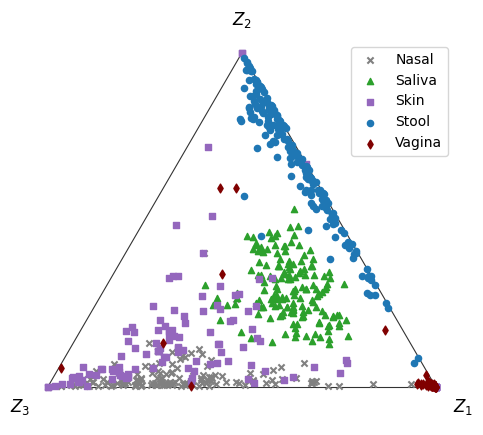

In [8]:
# Load the trained result
with open("results/ternary_train/HMP.pkl", "rb") as f:
    result = pickle.load(f)

P = result['CV_fitted_P'].numpy()
P[[1, 2]] = P[[2, 1]] # row exchange for visual compatibility
Z = (X @ P.T)

figure, tax = ternary.figure(scale=1)
tax.boundary(linewidth=0.8, alpha=0.8, zorder=1)

# Color and markers
color_list = [None, 'tab:blue', 'tab:green', 'tab:purple', 'gray', 'maroon']
marker_list = [None, 'o', '^', 's', 'x', 'd']

# Scatter plots
for i in [4, 2, 3, 1, 5]:
    tax.scatter(Z[Y == groups[i]], marker=marker_list[i], color=color_list[i], label=groups[i], s=20)

tax.legend()
corner_labeling(tax)

figure.set_size_inches(5.5, 5, forward=True) # Size forcing
tax.savefig("results/images/HMP.pdf", dpi=500, bbox_inches='tight')
tax.show()

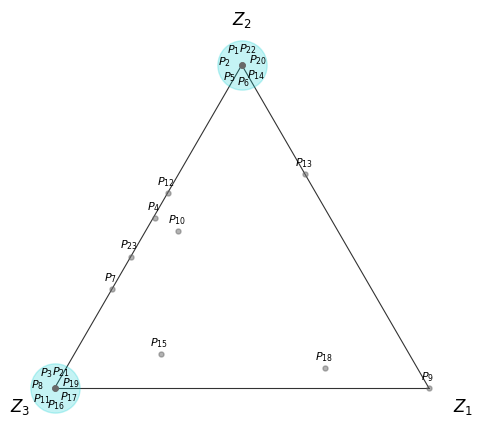

In [9]:
from functions.plot_helper import symmetric_radial_positions

# Variable allocation plot
fig, tax = ternary.figure(scale=1)
tax.boundary(linewidth=0.8, alpha=0.8, zorder=1)
tax.scatter(P.T, 
            c="dimgray",
            # c="darkblue", # alpha=0.27 
            marker='o', s=13, alpha=0.5,
             zorder=3)

# Make bubbles at the corners
# Bubbles for visual indication of overlappings at vertices (90% threshold?)
threshold = 0.9
s = 180
power = 1
non_annot = {}
for j in range(1, 3):
    # Positions of the columns which lie near the j-th vertex
    pos = np.where(P[j, :] > threshold)[0]
    if len(pos) > 0:
        # Store
        non_annot[j] = pos

        # bubble size
        size = s * len(pos) ** power
        # Vertex position
        vert = np.zeros((1, 3))
        vert[:, j] = 1.0
        # Plot large bubble
        tax.scatter(vert, c="darkturquoise", marker='o', s=size, alpha=0.23, zorder=2)

        # Add column names symmetrically
        radius = 0.0065 + 0.0057 * len(pos) # radius of the annotation texts
        positions = symmetric_radial_positions(vert[0], radius, len(pos))
        for i, position in enumerate(positions):
            # Annotate the column names
            col_name = f"$P_{{{pos[i]+1}}}$"
            tax.annotate(col_name, position, fontsize=8, color='black', ha='center', va='center', zorder=4)

# Add the variable names
for i in range(P.shape[1]):
    if i in non_annot[1] or i in non_annot[2]:
        continue
    else:
        # Otherwise, annotate the variable
        tax.annotate(f"$P_{{{i+1}}}$", P[:, i], fontsize=8, 
                     xytext=(-1, 3), textcoords='offset points', # convenient offset
                     ha='center', va='bottom', 
                     color="k", zorder=4)

# Add the radial positions


# Set the axis limits
ax = tax.get_axes()  # get matplotlib default axis
ax.set_xlim(-0.07, 1.07)
ax.set_ylim(-0.1, 0.933)

corner_labeling(tax) # label the corners (vertices)
fig.set_size_inches(5.5, 5, forward=True) # Size forcing
fig.savefig("results/images/HMP_bubble.pdf", dpi=500, bbox_inches='tight')
fig.show()

`rpy2` implementation of the SDR-normal method by Tommassi et al. (2021)

In [11]:
from reproducibility.other_methods.rpy2setup import setup_r_environment
setup_r_environment()

import rpy2.robjects as ro
from rpy2.robjects import numpy2ri
import warnings

# Use count matrix for SDR-normal
X_counts = counts[:, counts.sum(0) > 5]
# Suppress rpy2 console encoding warnings
warnings.filterwarnings('ignore', category=UnicodeWarning)
warnings.filterwarnings('ignore', message='.*cffi callback.*')

# Activate automatic conversion between numpy and R
numpy2ri.activate()

# Convert Python objects to R objects
r_X_counts = numpy2ri.py2rpy(X_counts)
r_Y = numpy2ri.py2rpy(labels.values.ravel())

# Assign them to R environment
ro.globalenv['X_counts'] = r_X_counts
ro.globalenv['Y'] = r_Y

# Temporarily set the working directory to the location of sdrtools.R
os.chdir('./reproducibility/other_methods/sdr4comp')

# Source the sdrtools.R script (suppress R console output to avoid encoding issues)
ro.r('options(warn=-1)')  # Suppress R warnings temporarily
ro.r('source("sdrtools.R")')

ro.r('normal_fit <- sdr4normal.fit(X_counts, Y, dim=2)')
ro.r('projLN <- sdr4normal.project(normal_fit, X_counts)')

# Return to the python array from R
proj_data = np.array(ro.r('projLN'))

# Return to the original directory
os.chdir('../../..') 

Using existing R_HOME: C:\Program Files\R\R-4.4.1
Lambda: 0  nr.var: 44 


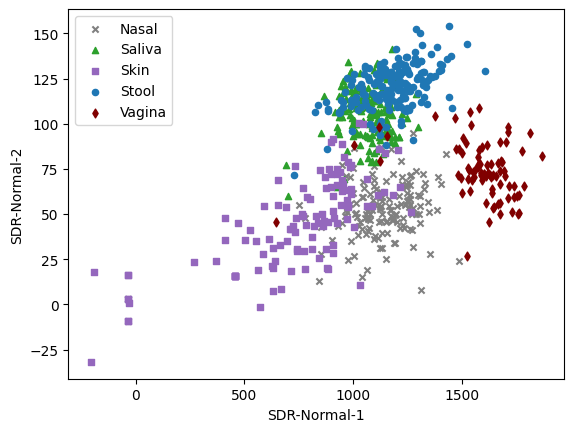

In [12]:
plt.figure()
# Scatter plots
for i in [4, 2, 3, 1, 5]:
    plt.scatter(proj_data[Y == groups[i], 0], proj_data[Y == groups[i], 1], marker=marker_list[i], color=color_list[i], label=groups[i], s=20)

plt.xlabel("SDR-Normal-1")
plt.ylabel("SDR-Normal-2")
plt.legend()
plt.show()

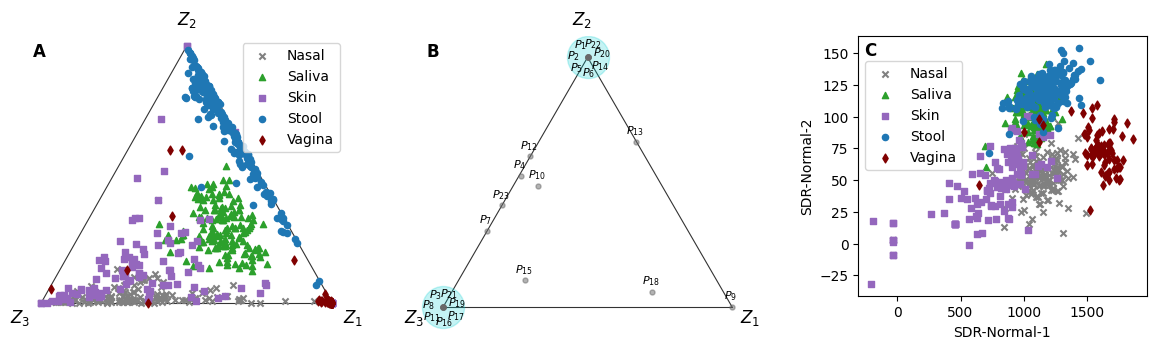

In [13]:
# Color and markers
color_list = [None, 'tab:blue', 'tab:green', 'tab:purple', 'gray', 'maroon']
marker_list = [None, 'o', '^', 's', 'x', 'd']

gridspec_kw = {'width_ratios': [1, 1.01, -0.1, 0.9]}
fig, ax = plt.subplots(1, 4, figsize=(11.5, 3.7), gridspec_kw=gridspec_kw)

ax[2].axis('off')  # Empty axis for spacing

# First plot: CKDR
_, tax = ternary.figure(scale=1, ax=ax[0])
tax.boundary(linewidth=0.8, alpha=0.8, zorder=1)

# Scatter plots
for i in [4, 2, 3, 1, 5]:
    tax.scatter(Z[Y == groups[i]], marker=marker_list[i], color=color_list[i], label=groups[i], s=20)

tax.legend(loc='upper right')
corner_labeling(tax)

# Second plot: variable allocation
_, tax = ternary.figure(scale=1, ax=ax[1])
tax.boundary(linewidth=0.8, alpha=0.8, zorder=1)

# Scatter plots of columns of P
tax.scatter(P.T, c="dimgray", marker='o', s=13, alpha=0.5, zorder=3)

# Make bubbles at the corners
# Bubbles for visual indication of overlappings at vertices (90% threshold?)
threshold = 0.9
s = 73
power = 1.3
non_annot = {}
for j in range(1, 3):
    # Positions of the columns which lie near the j-th vertex
    pos = np.where(P[j, :] > threshold)[0]
    if len(pos) > 0:
        # Store
        non_annot[j] = pos

        # bubble size
        size = s * len(pos) ** power
        # Vertex position
        vert = np.zeros((1, 3))
        vert[:, j] = 1.0
        # Plot large bubble
        tax.scatter(vert, c="darkturquoise", marker='o', s=size, alpha=0.23, zorder=2)

        # Add column names symmetrically
        radius = 0.008 + 0.0062 * len(pos) # radius of the annotation texts
        positions = symmetric_radial_positions(vert[0], radius, len(pos))
        for i, position in enumerate(positions):
            # Annotate the column names
            col_name = f"$P_{{{pos[i]+1}}}$"
            tax.annotate(col_name, position, fontsize=8, color='black', ha='center', va='center', zorder=4)

# Add the variable names
for i in range(P.shape[1]):
    if i in non_annot[1] or i in non_annot[2]:
        continue
    else:
        # Otherwise, annotate the variable
        tax.annotate(f"$P_{{{i+1}}}$", P[:, i], fontsize=8, 
                     xytext=(-1, 3), textcoords='offset points', # convenient offset
                     ha='center', va='bottom', 
                     color="k", zorder=4)

# Set the axis limits
# mat_ax = tax.get_axes()  # get matplotlib default axis
ax[1].set_xlim(-0.08, 1.04)
ax[1].set_ylim(-0.09, 0.94)
corner_labeling(tax) # label the corners (vertices)

# Third plot: SDR-normal
# SDR-normal (moved upwards)
for i in [4, 2, 3, 1, 5]:
    ax[3].scatter(proj_data[Y == groups[i], 0], proj_data[Y == groups[i], 1],
                  marker=marker_list[i], color=color_list[i], label=groups[i], s=20)
ax[3].set_xlabel("SDR-Normal-1")
ax[3].set_ylabel("SDR-Normal-2")
ax[3].legend(loc='upper left', bbox_to_anchor=(0, 0.93))

for label, axis in zip(['A', 'B', 'C'], [ax[0], ax[1], ax[3]]):
    axis.text(0.02, 0.98, label, transform=axis.transAxes,
              fontsize=12, fontweight='bold', ha='left', va='top')

original_tight_layout = fig.tight_layout

def _tight_layout_with_shift(*args, **kwargs):
    original_tight_layout(*args, **kwargs)
    pos = ax[3].get_position()
    shift = 0.1
    height_reduction = 0.1
    ax[3].set_position([pos.x0, pos.y0 + shift, pos.width, pos.height - height_reduction])

fig.tight_layout = _tight_layout_with_shift
fig.tight_layout()
fig.savefig("results/images/HMP_comparison.pdf", dpi=700, bbox_inches='tight')
fig.show()

# Ileum Microbiome data (Sec 5.2)

In [4]:
name = "gevers"
counts = pd.read_csv(directory + name + x_dir, sep='\t')
y_ileum = pd.read_csv(directory + name + y_dir + y_names[name] + ".txt", sep='\t')

counts2 = counts[y_ileum["#SampleID"]]

# Delete taxa present in less than 5 samples
taxa = counts["#OTU ID"][(counts2 > 0).sum(1) >= 5]
counts2 = counts2[(counts2 > 0).sum(1) >= 5]

x = counts2.to_numpy().T
y = y_ileum["Var"].to_numpy().flatten()

# Normalize
x = x / x.sum(1)[:, None]

y_vals = sorted(set(y))
print("Zero ratio:", np.sum(x == 0) / x.size)
print("Data shape", x.shape, " with y =", y_vals[0], "---", np.sum(y==y_vals[0]), "// y =", y_vals[1], "---", np.sum(y==y_vals[1]))

# Y processing (mandatory)
y = np.array([-1. if y == y_vals[0] else 1. for y in y])

Zero ratio: 0.8241899852724595
Data shape (140, 194)  with y = CD --- 78 // y = no --- 62


In [4]:
# Cross-validated CKDR
result = ckdr_cv_parallel(x, y, type_Y="binary", folds=5, verbose=True,
                          n_jobs=-3, seed=MASTER_SEED
                          )

# Save the result
with open("results/ternary_train/ileum.pkl", "wb") as f:
    pickle.dump(result, f)

Running parallel cross-validation with 10 parameter combinations across 5 folds, totaling 50 individual training tasks.


[Parallel(n_jobs=-3)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-3)]: Done  22 tasks      | elapsed:  2.9min
[Parallel(n_jobs=-3)]: Done  29 out of  50 | elapsed:  3.2min remaining:  2.3min
[Parallel(n_jobs=-3)]: Done  35 out of  50 | elapsed:  3.3min remaining:  1.4min
[Parallel(n_jobs=-3)]: Done  41 out of  50 | elapsed:  3.5min remaining:   45.9s
[Parallel(n_jobs=-3)]: Done  47 out of  50 | elapsed:  3.5min remaining:   13.4s
[Parallel(n_jobs=-3)]: Done  50 out of  50 | elapsed:  3.7min finished


\nSelected parameters after 5-fold Cross-validation (parallel):
  target_dim = 3, epsilon = 0.005994842503189409, sigma_Z = 0.4442
  Corresponding mean CV score: 0.7617
\nRefitting model with selected best parameters on the full dataset (parallel CV)...
Starting SCA CKDR on device: cpu
  n_samples=140, n_features=194, target_dim=3
  sigma=0.4442, epsilon=0.0060, tol=1.0e-06, inner_tol=1.0e-07
Iter:    0, Obj: 79.607079, LR: 1.00e+00, ||D||: 5.61e+00, inner residual: 1.08e+00, inner iters: 50
Iter:   10, Obj: 49.787224, LR: 1.00e+00, ||D||: 8.16e-01, inner residual: 4.78e-01, inner iters: 50
Iter:   20, Obj: 47.885796, LR: 1.00e+00, ||D||: 2.18e-01, inner residual: 3.71e-01, inner iters: 50
Iter:   30, Obj: 47.561478, LR: 1.00e+00, ||D||: 1.62e-01, inner residual: 9.16e-02, inner iters: 50
Iter:   40, Obj: 47.369686, LR: 1.00e+00, ||D||: 1.31e-01, inner residual: 6.75e-02, inner iters: 50
Iter:   50, Obj: 47.246376, LR: 1.00e+00, ||D||: 8.47e-02, inner residual: 5.09e-02, inner iters: 5

Train accuracy: 0.9928571428571429


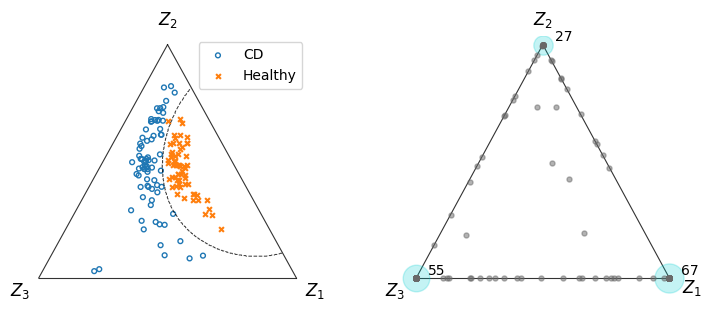

<Figure size 640x480 with 0 Axes>

In [5]:
# Load the result
with open("results/ternary_train/ileum.pkl", "rb") as f:
    result = pickle.load(f)
P = result['CV_fitted_P'].numpy()
P[[0, 2]] = P[[2, 0]]

gridspec_kw = {'width_ratios': [1, 0.05, 1]}
fig, ax = plt.subplots(1, 3, figsize=(8.5, 3.5), gridspec_kw=gridspec_kw)
ax[1].axis('off') # for spacing between the plots

# From ckdr class, I should extract the class labels
tern_scatter_decbdry(torch.tensor(P), model=result['CV_ckdr_class'], sigma=result['parameters']['sigma_Z'],
                     epsilon=result['parameters']['epsilon'], ax=ax[0], 
                     groups= ['CD', 'Healthy'],
                     marker_list=marker_list, color_list=colors,
                     facecolors='none', linecolor='black', linewidth=0.7)

# Variable allocation plot
_, tax = ternary.figure(scale=1, ax=ax[2])
tax.boundary(linewidth=0.8, alpha=0.8, zorder=1)
tax.scatter(P.T, 
            c="dimgray",
            # c="darkblue", # alpha=0.27 
            marker='o', s=13, alpha=0.5,
             zorder=3)
corner_labeling(tax, offset=[0.1, 0.2, 0.08]) # label the corners (vertices)

# Bubbles for visual indication of overlappings at vertices (90% threshold?)
threshold = 0.9
s = 10
power = 0.9
cluster_dict = {}
for j in range(3):
    # Positions of the columns which lie near the j-th vertex
    pos = np.where(P[j, :] > threshold)[0]
    cluster_dict[j + 1] = taxa.iloc[pos].values  # Store the clustered taxa
    if len(pos) > 0:
        # bubble size
        size = s * len(pos) ** power
        # Vertex position
        vert = np.zeros((1, 3))
        vert[:, j] = 1.0
        # Plot large bubble
        tax.scatter(vert, c="darkturquoise", marker='o', s=size, alpha=0.23, zorder=2)
        # Annotate the number of taxa
        vert = vert + np.array([[0.04, 0.015, -0.02]]) # offset for annotation
        tax.annotate(str(len(pos)), vert.ravel(), fontsize=10, zorder=4
                    #   color=plt.cm.jet(0.95),
                     )

ax[2].set_xlim([-0.06, 1.06]) # ylim adjustment: -0.1, 0.92

# save
fig.savefig("results/images/ileum.pdf", dpi=600, bbox_inches='tight')
fig.show()

In [6]:
# Downstream interpretation
cluster_dict = {}

idx_z1 = np.where(P[0, :] > 10 * P[2, :])[0]
idx_z3 = np.where(P[2, :] > 10 * P[0, :])[0]

cluster_dict[1] = taxa.iloc[idx_z1].values
cluster_dict[3] = taxa.iloc[idx_z3].values

# Taxa in the clusters at z1 and z3
cluster_dict

{1: array(['k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium',
        'k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Tannerellaceae;g__Parabacteroides;s__Parabacteroides distasonis',
        'k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides;s__Bacteroides salyersiae',
        'k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides;s__Bacteroides plebeius;t__Bacteroides plebeius DSM 17135',
        'k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides;s__Bacteroides stercoris',
        'k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Barnesiellaceae;g__Coprobacter;s__Coprobacter fastidiosus;t__Coprobacter fastidiosus NSB1',
        'k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Odoribacteraceae;g__Butyricimonas',
        'k__Bacteria;p__Bacteroidetes;c

In [7]:
from collections import defaultdict
from reproducibility.table_export import generate_taxa_table, extract_genus_from_taxonomic_string

# Generate the table
output_file = "results/tables/ileum_taxa.tex"
table_content = generate_taxa_table(
    {"CD": cluster_dict[3], "Healthy": cluster_dict[1]},
    output_file, "Ileum", top=5, show_other=False, show_total=False
)

# Display detailed summary for debugging
print("\n" + "="*60)
print("DETAILED CLUSTER ANALYSIS:")
print("="*60)
for cluster_id in sorted(cluster_dict.keys()):
    taxa_list = cluster_dict[cluster_id]
    print(f"\nCluster z_{cluster_id}: {len(taxa_list)} taxa")
    
    # Debug: show how each taxon is processed
    genus_counts = defaultdict(int)
    unclassified = []
    
    for taxa_string in taxa_list:
        genus = extract_genus_from_taxonomic_string(taxa_string)
        if genus:
            genus_counts[genus] += 1
        else:
            unclassified.append(taxa_string)
    
    print(f"  - {len(genus_counts)} distinct genera")
    
    # Show top genera
    if genus_counts:
        top_genera = sorted(genus_counts.items(), key=lambda x: x[1], reverse=True)[:5]
        print(f"  - Most abundant: {', '.join([f'{g}({c})' for g, c in top_genera])}")

print(f"\nFinal table generated with {len(table_content)} lines of LaTeX code.")

LaTeX table saved to: results/tables/ileum_taxa.tex

DETAILED CLUSTER ANALYSIS:

Cluster z_1: 77 taxa
  - 46 distinct genera
  - Most abundant: Parabacteroides(4), Eubacterium(4), Blautia(4), Roseburia(4), Erysipelatoclostridium(4)

Cluster z_3: 68 taxa
  - 48 distinct genera
  - Most abundant: Bacteroides(7), Tyzzerella(3), Lachnoclostridium(3), Dialister(3), Haemophilus(3)

Final table generated with 14 lines of LaTeX code.


# Vaginal Microbiome data (Appendix A)

In [8]:
name = "ravel"
counts = pd.read_csv(directory + name + x_dir, sep='\t')

Y= pd.read_csv(directory + name + y_dir + y_names[name] + ".txt", sep='\t')

counts2 = counts[Y["#SampleID"]]

# Delete taxa present in less than 5 samples
taxa = counts["#OTU ID"][(counts2 > 0).sum(1) >= 5]
counts2 = counts2[(counts2 > 0).sum(1) >= 5]

X = counts2.to_numpy().T
Y = Y["Var"].to_numpy().flatten()

# Normalize
X = X / X.sum(1)[:, None]

print("Zero ratio:", np.sum(X == 0) / X.size)
print("Data shape", X.shape, " with Y ranges", Y.min(), "to", Y.max())

Zero ratio: 0.9146917910766993
Data shape (388, 241)  with Y ranges 0 to 10


In [ ]:
# Cross-validated CKDR (8min with 14 cores)
result = ckdr_cv_parallel(X, Y, type_Y=None, folds=5, verbose=True,
                          n_jobs=-3, seed=MASTER_SEED,
                          )

# Save the result
with open("results/ternary_train/vaginal.pkl", "wb") as f:
    pickle.dump(result, f)

Running parallel cross-validation with 10 parameter combinations across 5 folds, totaling 50 individual training tasks.


[Parallel(n_jobs=-3)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-3)]: Done  22 tasks      | elapsed:  5.1min
[Parallel(n_jobs=-3)]: Done  29 out of  50 | elapsed:  5.8min remaining:  4.2min
[Parallel(n_jobs=-3)]: Done  35 out of  50 | elapsed:  6.5min remaining:  2.8min
[Parallel(n_jobs=-3)]: Done  41 out of  50 | elapsed:  6.9min remaining:  1.5min
[Parallel(n_jobs=-3)]: Done  47 out of  50 | elapsed:  7.2min remaining:   27.6s
[Parallel(n_jobs=-3)]: Done  50 out of  50 | elapsed:  7.4min finished


\nSelected parameters after 5-fold Cross-validation (parallel):
  target_dim = 3, epsilon = 0.003593813663804626, sigma_Z = 0.9658
  Corresponding mean CV score: 0.2968
\nRefitting model with selected best parameters on the full dataset (parallel CV)...
Starting SCA CKDR on device: cpu
  n_samples=388, n_features=241, target_dim=3
  sigma=0.9658, epsilon=0.0036, tol=1.0e-06, inner_tol=1.0e-07
Iter:    0, Obj: 97.405731, LR: 1.00e+00, ||D||: 1.95e+00, inner residual: 3.29e+00, inner iters: 50
Iter:   10, Obj: 80.683746, LR: 1.00e+00, ||D||: 2.54e-01, inner residual: 6.05e-01, inner iters: 50
Iter:   20, Obj: 79.121872, LR: 1.00e+00, ||D||: 2.55e-01, inner residual: 7.49e-01, inner iters: 50
Iter:   30, Obj: 77.089050, LR: 1.00e+00, ||D||: 3.25e-01, inner residual: 2.32e-01, inner iters: 50
Iter:   40, Obj: 76.794746, LR: 1.00e+00, ||D||: 2.76e-01, inner residual: 1.57e-01, inner iters: 50
Iter:   50, Obj: 76.669312, LR: 1.00e+00, ||D||: 2.91e-01, inner residual: 1.10e-01, inner iters: 5

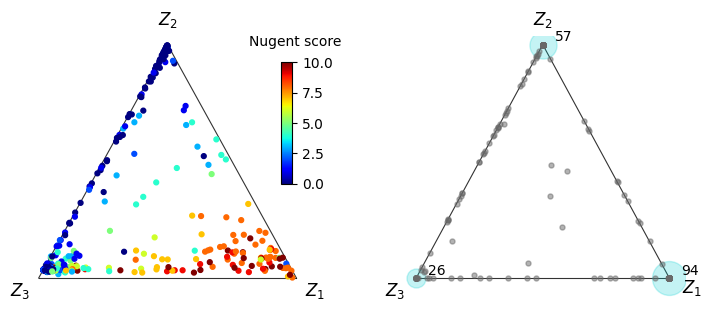

In [9]:
# Load the result
with open("results/ternary_train/vaginal.pkl", "rb") as f:
    result = pickle.load(f)

P = result['CV_fitted_P'].numpy()
P[[0, 1, 2]] = P[[1, 2, 0]]

Z = (X @ P.T)

gridspec_kw = {'width_ratios': [1, 0.05, 1]}
fig, ax = plt.subplots(1, 3, figsize=(8.5, 3.5), gridspec_kw=gridspec_kw)
ax[1].axis('off') # Just for spacing between the plots

cmap = plt.cm.jet
tern_scatter_cmap(Z, Y, ax=ax[0], show=False, cmap=cmap, cbar_label="Nugent score", label_position=[-1.3, -35.6])

# Variable allocation plot
_, tax = ternary.figure(scale=1, ax=ax[2])
tax.boundary(linewidth=0.8, alpha=0.8, zorder=1)
tax.scatter(P.T, 
            c="dimgray", 
            # c="darkblue", # alpha=0.27
            marker='o', s=13, alpha=0.5, 
             zorder=3)
corner_labeling(tax, offset=[0.1, 0.2, 0.08]) # label the corners (vertices)

# Bubbles for visual indication of overlappings at vertices (90% threshold?)
threshold = 0.9
s = 10
power = 0.9
cluster_dict = {}
for j in range(3):
    # Positions of the columns which lie near the j-th vertex
    pos = np.where(P[j, :] > threshold)[0]
    cluster_dict[j + 1] = taxa.iloc[pos].values  # Store the clustered taxa
    if len(pos) > 0:
        # bubble size
        size = s * len(pos) ** power
        # Vertex position
        vert = np.zeros((1, 3))
        vert[:, j] = 1.0
        # Plot large bubble
        tax.scatter(vert, c="darkturquoise", marker='o', s=size, alpha=0.23, zorder=2)
        # Annotate the number of taxa
        vert = vert + np.array([[0.04, 0.014, -0.01]]) # offset for annotation
        tax.annotate(str(len(pos)), vert.ravel(), fontsize=10, zorder=4)

ax[2].set_xlim([-0.06, 1.06])

fig.savefig("results/images/vaginal.pdf", dpi=600, bbox_inches='tight')
fig.show()

In [10]:
# Downstream interpretation
cluster_dict = {}

idx_z1 = np.where(P[0, :] > 10 * P[1, :])[0]
idx_z2 = np.where(P[1, :] > 10 * P[0, :])[0]

cluster_dict[1] = taxa.iloc[idx_z1].values
cluster_dict[2] = taxa.iloc[idx_z2].values

# Taxa in the clusters at z1 and z2
cluster_dict

{1: array(['k__Bacteria;p__Actinobacteria;c__Actinobacteria',
        'k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Actinobaculum;s__Actinobaculum massiliense',
        'k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Actinomyces;s__Actinomyces ihumii',
        'k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Actinomyces;s__Actinomyces hongkongensis',
        'k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Actinomyces;s__Actinomyces europaeus',
        'k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Actinomyces;s__Actinomyces neuii;t__Actinomyces neuii subsp. anitratus',
        'k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Arcanobacterium',
        'k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Actinomycetales;f__Actinomycet

In [11]:
# Generate the table
output_file = "results/tables/vaginal_taxa.tex"
table_content = generate_taxa_table(
    {"High-Nugent": cluster_dict[1], "Low-Nugent": cluster_dict[2]},
    output_file, "Vaginal", top=5, show_other=False, show_total=False
)

# Display detailed summary for debugging
print("\n" + "="*60)
print("DETAILED CLUSTER ANALYSIS:")
print("="*60)
for cluster_id in sorted(cluster_dict.keys()):
    taxa_list = cluster_dict[cluster_id]
    print(f"\nCluster z_{cluster_id}: {len(taxa_list)} taxa")
    
    # Debug: show how each taxon is processed
    genus_counts = defaultdict(int)
    unclassified = []
    
    for taxa_string in taxa_list:
        genus = extract_genus_from_taxonomic_string(taxa_string)
        if genus:
            genus_counts[genus] += 1
        else:
            unclassified.append(taxa_string)
    
    print(f"  - {len(genus_counts)} distinct genera")
    
    # Show top genera
    if genus_counts:
        top_genera = sorted(genus_counts.items(), key=lambda x: x[1], reverse=True)[:5]
        print(f"  - Most abundant: {', '.join([f'{g}({c})' for g, c in top_genera])}")

print(f"\nFinal table generated with {len(table_content)} lines of LaTeX code.")

LaTeX table saved to: results/tables/vaginal_taxa.tex

DETAILED CLUSTER ANALYSIS:

Cluster z_1: 113 taxa
  - 53 distinct genera
  - Most abundant: Corynebacterium(9), Prevotella(9), Anaerococcus(9), Streptococcus(8), Peptoniphilus(8)

Cluster z_2: 92 taxa
  - 51 distinct genera
  - Most abundant: Streptococcus(8), Lactobacillus(6), Corynebacterium(5), Bacteroides(5), Peptoniphilus(4)

Final table generated with 14 lines of LaTeX code.
